# 26 — L'indice, mesuré sur un fil réel

Six chapitres de ce dépôt reposent sur une lacune énoncée comme définitive :

> Aucun jeu de données public ne porte à la fois le **rang servi** et une **étiquette de point
> de vue** interprétable. MIND a les catégories sans l'ordre, Baidu-ULTR l'ordre sans les
> catégories.

**EB-NeRD** porte les deux. Le journal du quotidien danois *Ekstra Bladet*, publié pour le
RecSys Challenge 2024, donne pour chaque impression la liste `article_ids_inview` — ce qui a été
servi — et rattache chaque article à une rubrique déclarée, `category_str`.

Ce chapitre lui applique les contrôles du dépôt, dans l'ordre, puis mesure ce qui reste
mesurable. La réponse tient en deux temps : le premier contrôle **retire l'ordre**, et ce qui
reste suffit tout de même à **borner** l'indice exposé — et parfois à trancher.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ide.ebnerd import catalogue_size, load_digest, signature_counts
from ide.entropy import effective_viewpoints, exposed_index_bounds
from ide.logs import detectable_severity, exchangeability_test
from ide.plotting import PALETTE, save_figure, use_project_style

use_project_style()
SEVERITY = 0.88  # la sévérité mesurée sur Baidu-ULTR, transportée faute de mieux — voir §5

# Le journal brut n'est pas versionné : le condensé porte la structure d'ordre des fils et
# leurs signatures de composition, et rend les mêmes chiffres — quatre tests le vérifient.
digest = load_digest()
CATALOGUE = catalogue_size(digest)
signatures, occurrences = signature_counts(digest, "feed")
print(f"{occurrences.sum():,} fils servis, {len(signatures):,} compositions distinctes")
print(f"catalogue déclaré : {CATALOGUE} rubriques")

232,887 fils servis, 13,725 compositions distinctes
catalogue déclaré : 26 rubriques


## 1. Le premier contrôle retire l'ordre

Le test d'échangeabilité demande si, **à fil donné**, les clics se concentrent sur les premières
places. Un biais de position le rend franchement négatif : sur Baidu-ULTR, $z = -206$.

In [2]:
verdict = exchangeability_test(digest.impressions("ebnerd"))
print(f"échangeabilité : z = {verdict.deviation:+.2f}   p = {verdict.p_value:.3f}   "
      f"({verdict.feeds_used:,} fils informatifs)")

# Un test qui ne rejette pas ne dit rien tant qu'on ignore ce qu'il aurait su rejeter.
seuil = detectable_severity(digest.splits["ebnerd"]["feed_lengths"], probe=0.02,
                            rng=np.random.default_rng(20260823))
print(f"\nsévérité que ce journal aurait détectée : η ≥ {seuil:.4f}")
print(f"sévérité mesurée sur Baidu-ULTR         : η = 0,88, soit {0.88/seuil:.0f} fois plus")

échangeabilité : z = +1.05   p = 0.294   (232,887 fils informatifs)



sévérité que ce journal aurait détectée : η ≥ 0.0066
sévérité mesurée sur Baidu-ULTR         : η = 0,88, soit 134 fois plus


Le silence n'est donc pas un défaut de puissance : ce journal aurait détecté une sévérité **cent
trente fois plus faible** que celle mesurée sur un moteur de recherche réel. `article_ids_inview`
est un **ensemble servi**, pas un fil ordonné.

C'est une déception utile. L'indice **exposé** — celui que ce dépôt propose au régulateur — n'est
pas mesurable ici. L'indice **aveugle au rang** l'est, et il ne l'a jamais été sur données réelles.

## 2. Ce qui devient mesurable : la diversité servie, pour de vrai

Deux fenêtres. Le **fil** — une impression, ce que la page a présenté d'un coup. Et la
**journée-utilisateur**, qui est la fenêtre que le [protocole du dépôt](../ide.md) prescrit : la
grandeur réglementaire n'est pas la moyenne, c'est la **part de la population sous le plancher**.

In [3]:
def indice_aveugle(signature):
    counts = np.asarray(signature, dtype=float)
    parts = counts[counts > 0]
    parts = parts / parts.sum()
    return float(-(parts * np.log2(parts)).sum() / np.log2(CATALOGUE))


def quantile(values, weights, probability):
    order = np.argsort(values)
    return values[order][np.searchsorted(np.cumsum(weights[order]), probability)]


mesures = {}
for fenetre, nom in (("feed", "fil servi"), ("user_day", "journée-utilisateur")):
    rows, counts = signature_counts(digest, fenetre)
    values = np.array([indice_aveugle(row) for row in rows])
    weights = counts / counts.sum()
    mesures[fenetre] = (values, weights, rows.sum(1))

    mediane = quantile(values, weights, 0.5)
    print(f"{nom:<22} médiane {mediane:.3f}   "
          f"quartiles [{quantile(values, weights, 0.25):.3f}, "
          f"{quantile(values, weights, 0.75):.3f}]   "
          f"points de vue effectifs {effective_viewpoints(mediane, CATALOGUE):.2f} sur {CATALOGUE}")
    for plancher in (0.40, 0.50, 0.60):
        print(f"    part sous {plancher:.2f} : {weights[values < plancher].sum():.3f}")

fil servi              médiane 0.417   quartiles [0.372, 0.489]   points de vue effectifs 3.89 sur 26
    part sous 0.40 : 0.350
    part sous 0.50 : 0.788
    part sous 0.60 : 0.987
journée-utilisateur    médiane 0.466   quartiles [0.411, 0.507]   points de vue effectifs 4.56 sur 26
    part sous 0.40 : 0.188
    part sous 0.50 : 0.712
    part sous 0.60 : 0.994


**C'est la première fois que ce dépôt publie ce chiffre sur autre chose qu'une simulation.**
Un lecteur d'*Ekstra Bladet* reçoit, dans une journée, l'équivalent de **4,6 rubriques également
servies sur 26**. Et un plancher fixé à $0{,}50$ — valeur d'illustration, non recommandation —
laisserait **71 %** des journées-utilisateur en dessous.

## 3. Ce qui reste de l'indice exposé : un encadrement

L'ordre manque, mais la composition est connue. L'indice exposé n'est donc pas déterminé — il est
**contraint**. `exposed_index_bounds` énumère toutes les mises en ordre distinctes et rend
l'encadrement exact.

Trois verdicts deviennent possibles : le fil est **sûrement sous** le plancher quelle que soit sa
mise en ordre, **sûrement au-dessus**, ou **indécidable**. La part indécidable est le prix exact
de la colonne manquante.

In [4]:
rows, counts = signature_counts(digest, "feed")
courts = rows.sum(1) <= 10  # au-delà, l'énumération exacte cesse d'être praticable
poids = counts[courts] / counts[courts].sum()
print(f"fils de dix contenus ou moins : {counts[courts].sum() / counts.sum():.1%} du journal")

bornes = np.array([exposed_index_bounds(tuple(int(v) for v in row[row > 0]), CATALOGUE, SEVERITY)
                   for row in rows[courts]])
basse, haute = bornes[:, 0], bornes[:, 1]
aveugle = np.array([indice_aveugle(row) for row in rows[courts]])

print(f"\nIDE aveugle au rang       médiane {quantile(aveugle, poids, 0.5):.3f}")
print(f"borne basse de l'exposé   médiane {quantile(basse, poids, 0.5):.3f}")
print(f"borne haute de l'exposé   médiane {quantile(haute, poids, 0.5):.3f}")
print(f"largeur de l'encadrement  médiane {quantile(haute - basse, poids, 0.5):.3f}")

print("\nplancher   sûrement sous   sûrement au-dessus   indécidable")
verdicts = {}
for plancher in (0.30, 0.40, 0.50):
    sous = poids[haute < plancher].sum()
    dessus = poids[basse >= plancher].sum()
    verdicts[plancher] = (sous, dessus, 1 - sous - dessus)
    print(f"   {plancher:.2f}         {sous:.3f}              {dessus:.3f}            "
          f"{1 - sous - dessus:.3f}")

fils de dix contenus ou moins : 63.6% du journal



IDE aveugle au rang       médiane 0.405
borne basse de l'exposé   médiane 0.301
borne haute de l'exposé   médiane 0.414
largeur de l'encadrement  médiane 0.104

plancher   sûrement sous   sûrement au-dessus   indécidable
   0.30         0.082              0.506            0.413
   0.40         0.324              0.079            0.597
   0.50         0.915              0.007            0.077


**Sans le rang, on peut condamner ; on n'acquitte presque jamais.** À un plancher de $0{,}40$,
un tiers des fils y contreviennent *quelle que soit* leur mise en ordre — c'est un constat
opposable, obtenu sans la colonne manquante. Mais huit pour cent seulement sont sûrement
conformes, et **six fils sur dix restent indécidables**.

## 4. Ce que l'encadrement doit à la sévérité supposée

In [5]:
print("η employé   largeur médiane   indécidables à 0,40")
sensibilite = {}
for severite in (0.5, SEVERITY, 1.1):
    essai = np.array([exposed_index_bounds(tuple(int(v) for v in row[row > 0]), CATALOGUE,
                                           severite) for row in rows[courts]])
    largeur = quantile(essai[:, 1] - essai[:, 0], poids, 0.5)
    indecis = 1 - poids[essai[:, 1] < 0.40].sum() - poids[essai[:, 0] >= 0.40].sum()
    sensibilite[severite] = (largeur, indecis)
    print(f"   {severite:.2f}          {largeur:.3f}             {indecis:.3f}")

η employé   largeur médiane   indécidables à 0,40


   0.50          0.062             0.402
   0.88          0.104             0.597


   1.10          0.127             0.422


La **largeur** de l'encadrement croît avec la sévérité, et c'est attendu : plus l'attention se
concentre, plus l'ordre décide. La **part indécidable**, elle, ne croît pas — elle culmine vers
$\eta \approx 0{,}9$ puis redescend, parce qu'à sévérité plus forte l'intervalle entier glisse
sous le plancher et le fil redevient décidable, par condamnation.

La conclusion ne dépend donc pas du chiffre retenu, mais pour une raison qu'il faut dire :
à $\eta = 1{,}1$, si quatre fils sur dix restent indécidables, c'est que les six autres sont
**sûrement en dessous**.

## 5. La figure

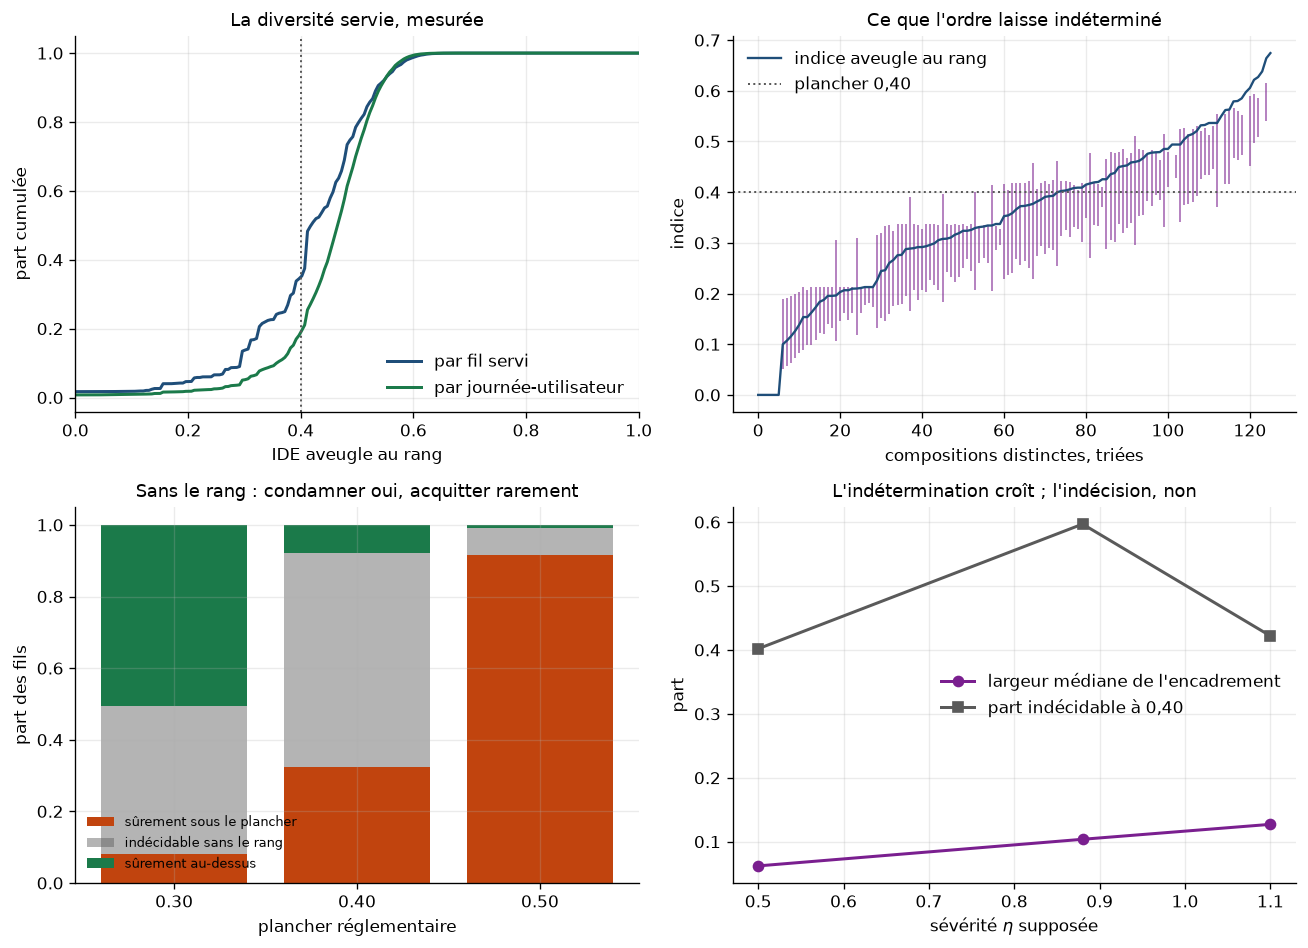

In [6]:
figure, axes = plt.subplots(2, 2, figsize=(11, 8))

ax = axes[0, 0]
for fenetre, nom, couleur in (("feed", "par fil servi", PALETTE["order"]),
                              ("user_day", "par journée-utilisateur", PALETTE["remedy"])):
    values, weights, _ = mesures[fenetre]
    grid = np.linspace(0, 1, 200)
    order = np.argsort(values)
    cumulative = np.cumsum(weights[order])
    ax.plot(grid, np.interp(grid, values[order], cumulative, left=0.0, right=1.0),
            color=couleur, label=nom)
ax.axvline(0.40, color=PALETTE["neutral"], linestyle=":", linewidth=1.2)
ax.set(xlabel="IDE aveugle au rang", ylabel="part cumulée", xlim=(0, 1),
       title="La diversité servie, mesurée")
ax.legend()

ax = axes[0, 1]
echantillon = np.argsort(aveugle)[::max(1, len(aveugle) // 400)]
ax.vlines(np.arange(echantillon.size), basse[echantillon], haute[echantillon],
          color=PALETTE["field"], alpha=0.55, linewidth=1.2)
ax.plot(np.arange(echantillon.size), aveugle[echantillon], color=PALETTE["order"],
        linewidth=1.4, label="indice aveugle au rang")
ax.axhline(0.40, color=PALETTE["neutral"], linestyle=":", linewidth=1.2, label="plancher 0,40")
ax.set(xlabel="compositions distinctes, triées", ylabel="indice",
       title="Ce que l'ordre laisse indéterminé")
ax.legend()

ax = axes[1, 0]
planchers = list(verdicts)
bas = np.array([verdicts[p][0] for p in planchers])
haut = np.array([verdicts[p][1] for p in planchers])
milieu = np.array([verdicts[p][2] for p in planchers])
ax.bar(range(len(planchers)), bas, color=PALETTE["disorder"], label="sûrement sous le plancher")
ax.bar(range(len(planchers)), milieu, bottom=bas, color=PALETTE["neutral"], alpha=0.45,
       label="indécidable sans le rang")
ax.bar(range(len(planchers)), haut, bottom=bas + milieu, color=PALETTE["remedy"],
       label="sûrement au-dessus")
ax.set(xticks=range(len(planchers)), xticklabels=[f"{p:.2f}" for p in planchers],
       xlabel="plancher réglementaire", ylabel="part des fils",
       title="Sans le rang : condamner oui, acquitter rarement")
ax.legend(loc="lower left", fontsize=8)

ax = axes[1, 1]
severites = list(sensibilite)
ax.plot(severites, [sensibilite[s][0] for s in severites], marker="o",
        color=PALETTE["field"], label="largeur médiane de l'encadrement")
ax.plot(severites, [sensibilite[s][1] for s in severites], marker="s",
        color=PALETTE["neutral"], label="part indécidable à 0,40")
ax.set(xlabel="sévérité $\\eta$ supposée", ylabel="part",
       title="L'indétermination croît ; l'indécision, non")
ax.legend()

save_figure(figure, "fig26_indice_mesure.png")
plt.show()

## 6. Ce que ce chapitre change

**La lacune était mal énoncée.** Ce n'est pas qu'aucun jeu public ne porte les deux colonnes :
EB-NeRD les porte. C'est que **la colonne de rang, là où elle existe, ne contient pas le rang**.
La demande au titre de l'[article 40](../article-40.md) doit donc réclamer non pas « le rang »
mais le rang **vérifiable** — et le test d'échangeabilité est ce qui le vérifie.

**L'indice a enfin un chiffre réel.** $0{,}47$ par journée-utilisateur, soit $4{,}6$ rubriques
également servies sur $26$. Ce chiffre ne dit pas si c'est peu ou beaucoup — c'est une décision
politique, comme le [dépôt le répète](../ide.md) — mais il donne l'ordre de grandeur qui manquait
à toute discussion de plancher.

**Et l'absence du rang se chiffre.** $0{,}104$ d'indétermination médiane, six fils sur dix
indécidables à un plancher de $0{,}40$. C'est ce que coûte, en pratique, une colonne que la
plateforme possède et ne publie pas.

**Réserves.** `category_str` est une **rubrique**, non un point de vue : la mesure porte sur la
diversité *thématique*, substitut déjà employé sur MIND et qui doit être lu comme tel. La
sévérité $\eta = 0{,}88$ est **transportée** de Baidu-ULTR, un moteur de recherche : le
[chapitre 25](../effet-de-page.md) a établi qu'elle se transporte d'une page à l'autre, pas d'une
plateforme à l'autre — d'où le test de sensibilité du §4. Le catalogue de $26$ rubriques est
celui du corpus, non un catalogue de référence imposé. Enfin l'encadrement exact ne couvre que
les fils de dix contenus ou moins, soit $64\,\%$ du journal.